<a href="https://colab.research.google.com/github/vivek1905/Vivek_Foundations-of-AI-code-for-the-Final-Report/blob/main/Vivek_FAI_Code_for_Capstone_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
# IMPORT LIBRARIES
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
import random

In [24]:
# Set random seed for reproducibility
np.random.seed(42)
random.seed(42)

In [25]:
# ENVIRONMENT SETUP
env = gym.make("FrozenLake-v1", is_slippery=True)

state_size = env.observation_space.n
action_size = env.action_space.n

print("State size:", state_size)
print("Action size:", action_size)

State size: 16
Action size: 4


In [26]:
# INITIALIZE Q-TABLE
q_table = np.zeros((state_size, action_size))

print(q_table)

[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


In [27]:
# HYPERPARAMETERS

learning_rate = 0.1
discount_factor = 0.99

epsilon = 1.0
epsilon_decay = 0.995
min_epsilon = 0.01

episodes = 5000
max_steps = 100

In [28]:
# TRACKING METRICS
rewards = []
success_rate = []

# TRAINING LOOP
for episode in range(episodes):

    state, _ = env.reset()
    total_reward = 0

    for step in range(max_steps):

        # Exploration vs Exploitation
        if np.random.uniform(0,1) < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state])
        next_state, reward, terminated, truncated, _ = env.step(action)

        # Q-Learning Update
        q_table[state, action] = q_table[state, action] + learning_rate * (
            reward + discount_factor * np.max(q_table[next_state]) - q_table[state, action]
        )

        state = next_state
        total_reward += reward

        if terminated or truncated:
            break

    # Update Exploration Rate
    epsilon = max(min_epsilon, epsilon * epsilon_decay)

    rewards.append(total_reward)
    success = 1 if total_reward > 0 else 0
    success_rate.append(success)

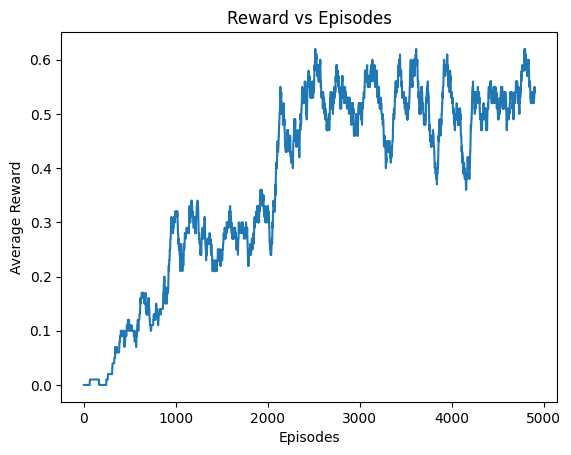

In [29]:
# PLOT RESULTS FOR REWARD CURVE
plt.figure()
plt.plot(np.convolve(rewards, np.ones(100)/100, mode='valid'))
plt.title("Reward vs Episodes")
plt.xlabel("Episodes")
plt.ylabel("Average Reward")
plt.savefig("reward_plot.png")
plt.show()

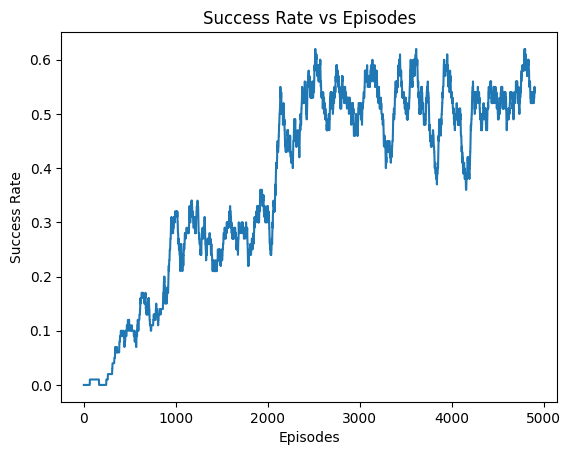

In [30]:
# PLOT RESULTS FOR SUCCESS RATE CURVE
plt.figure()
plt.plot(np.convolve(success_rate, np.ones(100)/100, mode='valid'))
plt.title("Success Rate vs Episodes")
plt.xlabel("Episodes")
plt.ylabel("Success Rate")
plt.savefig("success_plot.png")
plt.show()

In [31]:
# TEST TRAINED AGENT
test_episodes = 100
success = 0

for episode in range(test_episodes):

    state, _ = env.reset()

    for step in range(max_steps):

        action = np.argmax(q_table[state])
        next_state, reward, terminated, truncated, _ = env.step(action)

        state = next_state

        if terminated or truncated:
            success += reward
            break

print("Success Rate:", success / test_episodes)
# Print average reward
print("Average Reward (last 100 episodes):", np.mean(rewards[-100:]))

Success Rate: 0.63
Average Reward (last 100 episodes): 0.54


In [32]:
# FINAL OUTPUTS
print("Final Q Table:")
print(q_table)

Final Q Table:
[[0.43008158 0.32864234 0.31160694 0.34961317]
 [0.18192312 0.04431806 0.00834656 0.03682466]
 [0.22412565 0.01647391 0.05392904 0.02253067]
 [0.0069753  0.         0.         0.        ]
 [0.44382591 0.30855723 0.22869559 0.32416986]
 [0.         0.         0.         0.        ]
 [0.31782348 0.07644591 0.09142542 0.03883229]
 [0.         0.         0.         0.        ]
 [0.33734498 0.28217125 0.19803254 0.47255249]
 [0.26364543 0.51870404 0.36580203 0.26409562]
 [0.58402912 0.26870437 0.27776973 0.20335583]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.2767471  0.29089287 0.61532555 0.27684075]
 [0.45802409 0.46195395 0.39323144 0.79480771]
 [0.         0.         0.         0.        ]]


In [33]:
actions = ['←','↓','→','↑']
policy = np.argmax(q_table, axis=1)

grid = np.array([actions[a] for a in policy]).reshape(4,4)

print("\nLearned Policy:")
print(grid)


Learned Policy:
[['←' '←' '←' '←']
 ['←' '←' '←' '←']
 ['↑' '↓' '←' '←']
 ['←' '→' '↑' '←']]
